# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map
from moments.optimization import optimize_moment_preserving_entanglement

# Space definition and discretization

In [2]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

## Analytical conditions

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy certain constraints.
In particular, those are

- $x, y, z \ge 0$,
- $z \ge x + y - 1$,
- $z^2 \le 3 + x^2 + y^2 - 4xy - 4|x-y|$,
- $x = y$.

Therefore, is the intersection of a region in the first quadrant and the plane $x=y$. Since $x=y$, the inequalities become:

- $x, z \ge 0$,
- $z \ge 2x - 1$,
- $z \le \sqrt{3 - 2 x^2}$.

In [3]:
D = 40
Dx, Dz = D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')
Y = X

mask1 = Z >= 2*X - 1
mask2 = Z**2 <= 3 - 2*X**2

mask = mask1 & mask2
indices = np.where(mask)
total_points = len(indices[0])

points = np.column_stack((X[mask], X[mask], Z[mask]))
print(f"Number of points: {points.shape}")

Number of points: (2064, 3)


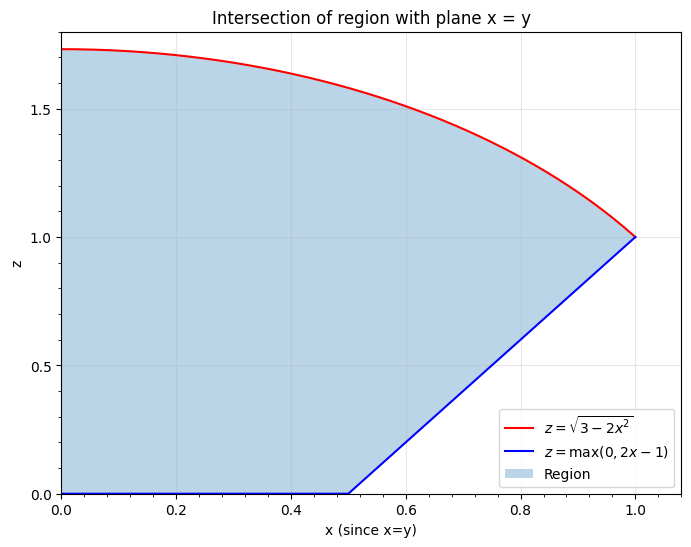

In [4]:
# Create a fine grid for plotting
x_plot = np.linspace(0, 1, 500)
z_upper = np.sqrt(3 - 2*x_plot**2)

# Lower boundary: max(0, 2x-1)
z_lower = np.maximum(0, 2*x_plot - 1)

# Plot
fig, ax = plt.subplots(figsize = (8, 6))

ax.plot(x_plot, z_upper, 'r-', label=r'$z = \sqrt{3 - 2x^2}$')
ax.plot(x_plot, z_lower, 'b-', label=r'$z = \max(0, 2x-1)$')
ax.fill_between(x_plot, z_lower, z_upper, alpha=0.3, label='Region')

ax.set(xlabel = 'x (since x=y)',  ylabel = 'z', title = 'Intersection of region with plane x = y',
       xlim = (0, 1.08), ylim = (0, 1.8), xticks = np.arange(0, 1.11, 0.2), yticks = np.arange(0, 1.81, 0.5))
ax.set_xticks(np.arange(0, 1.11, 0.04), minor = True)
ax.set_yticks(np.arange(0, 1.81, 0.1), minor = True)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.show()

# Optimization

In [ ]:
success, times = [], []
max_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    y_val = Y[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}

    optimization_result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                              metric="concurrence", optimization="maximize", cholesky_opt=True)
    
    max_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    # Progress tracker
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (2064/2064) | Time for this point: 0.172 s

Done!
Successful optimizations: 1981/2064 | Percentage: 95.98
Total time: 4.44 min | Average time: 0.129 s


In [6]:
success, times = [], []
min_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    y_val = Y[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}

    optimization_result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                              metric="concurrence", optimization="minimize", cholesky_opt=True)
    
    min_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    # Progress tracker
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (2064/2064) | Time for this point: 0.162 s

Done!
Successful optimizations: 1983/2064 | Percentage: 96.08
Total time: 2.70 min | Average time: 0.078 s


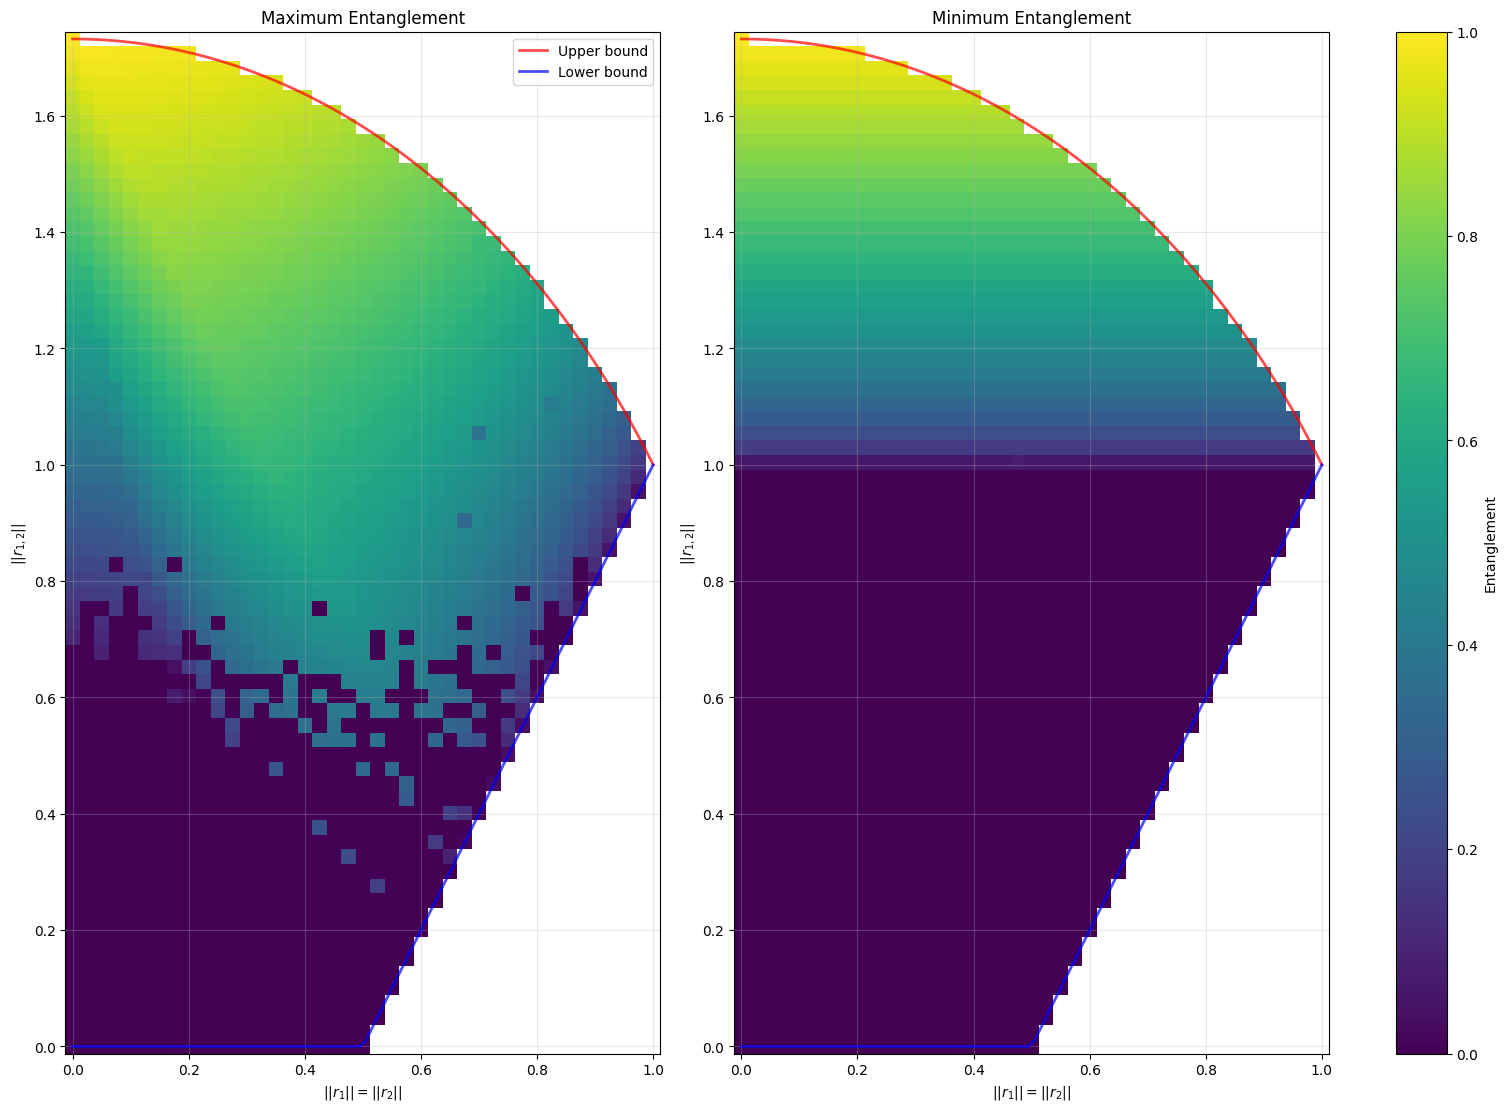

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 11), constrained_layout=True)

mesh0 = ax[0].pcolormesh(X, Z, max_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(X, Z, min_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$")
ax[1].set(xlabel = r"$|| r_1 || = || r_2 ||$", ylabel = r"$||r_{1, 2}||$")

ax[0].set_title('Maximum Entanglement')
ax[1].set_title('Minimum Entanglement')

x_boundary = np.linspace(0, 1, 100)
z_upper = np.sqrt(3 - 2*x_boundary**2)
z_lower = np.maximum(0, 2*x_boundary - 1)

ax[0].plot(x_boundary, z_upper, 'r-', linewidth=2, alpha=0.7, label='Upper bound')
ax[0].plot(x_boundary, z_lower, 'b-', linewidth=2, alpha=0.7, label='Lower bound')
ax[1].plot(x_boundary, z_upper, 'r-', linewidth=2, alpha=0.7)
ax[1].plot(x_boundary, z_lower, 'b-', linewidth=2, alpha=0.7)

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()